# Discovering the Menu

Tengri is plugin-aware. The library knows what physics it ships, which
inference backends are installed and compatible with a given model,
what filters are on disk, and how to fetch missing SSP grids. Asking
Python is faster than reading docs.

In [1]:
import os

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"  # suppress XLA/PjRt C++ INFO+WARNING logs

import warnings

# Keep the rendered tutorial clean: silence framework notices that do not
# change the science shown here (baked-in nebular, the WavePrecomp blue-band
# approximation, and
# recipe/parameter-provenance notices). Genuine deprecations in user-facing
# calls are fixed in the code, not hidden.
#
# WildcardPartialFreeWarning is deliberately NOT silenced. This notebook is
# about discovering what the menu offers, and that warning is the discovery:
# it names the parameters an `all_params: FREE` wildcard could not free
# because they carry only a Fixed default. Hiding it here would leave a
# reader to meet it for the first time alone, in their own code.
warnings.filterwarnings("ignore", message=".*BakedInBackend.*")
warnings.filterwarnings("ignore", message=".*WavePrecomp.*")
warnings.filterwarnings("ignore", message=".*was marked FIXED.*")
warnings.filterwarnings("ignore", message=".*Composable AGN.*")
warnings.filterwarnings("ignore", message=".*before the Big Bang.*")
warnings.filterwarnings("ignore", category=RuntimeWarning)

import inspect
from pathlib import Path

import jax
import matplotlib.pyplot as plt
import numpy as np

from _setup import FIG_DIR
import tengri
from tengri import (
    FIXED,
    Observation,
    Photometry,
    SEDModel,
    builders,
    citations,
    plot,
    recipes,
)

plot.setup_style()

## Bird's eye

In [2]:
tengri.summary()


tengri — what's available:

  Core classes (the four nouns inference talks to):
    tengri.SEDModel         differentiable SED forward chain
    tengri.ForwardModel     outer shell — owns SED + observation, exposes .predict / .predict_observables
    tengri.Parameters       priors + fixed values
    tengri.Fitter           inference driver

     7  physics components           tengri.list_components()
     1  AGN models                   tengri.list_agn_models()
    22  dust attenuation laws        tengri.list_dust_laws()
    19  dust emission templates      tengri.list_dust_emission_models()
    26  buildable SFH models         tengri.list_sfh_models(status='production')
    34  total SFH models             tengri.list_sfh_models()
     5  nebular backends             tengri.list_nebular_backends()
   249  photometric filters          tengri.list_filters()
    10  plotting helpers             tengri.list_plots()
     8  primary inference methods    tengri.list_inference_methods(tier=

## SSP catalogs

Bare-stellar grids (e.g. `fsps_prsc_miles_chabrier`) pair with the Cue
nebular emulator; "wNE" grids carry baked-in nebular emission and pair
with the `ssp` nebular backend. `download_ssp` fetches missing grids on
demand.

In [3]:
tengri.list_known_ssps()

name,filename
bc03_pdva_stelib_chabrier,bc03_pdva_stelib_chabrier.h5
bpss_stars_c3k_a_chabrier,bpss_stars_c3k_a_chabrier.h5
fsps_bsti_basel_chabrier,fsps_bsti_basel_chabrier.h5
fsps_bsti_c3k_a_chabrier,fsps_bsti_c3k_a_chabrier.h5
fsps_bsti_miles_chabrier,fsps_bsti_miles_chabrier.h5
fsps_mist_basel_chabrier,fsps_mist_basel_chabrier.h5
fsps_mist_c3k_a_chabrier,fsps_mist_c3k_a_chabrier.h5
fsps_mist_c3k_a_kroupa,fsps_mist_c3k_a_kroupa.h5
fsps_mist_c3k_a_salpeter,fsps_mist_c3k_a_salpeter.h5
fsps_mist_miles_chabrier,fsps_mist_miles_chabrier.h5


In [4]:
ssp = tengri.load_ssp("fsps_prsc_miles_chabrier", download=True)

## Star-formation history variants

Each entry of `builders.sfh.available()` is a real callable whose
signature lists its parameters with default priors. Notebook
autocompletion works on it.

In [5]:
builders.sfh.available()

['buat08',
 'burst',
 'const',
 'const_exp',
 'continuity',
 'continuity_flex',
 'delayed',
 'delayed_bq',
 'dense_basis',
 'dense_basis_pure',
 'dexp',
 'dirichlet',
 'dpl',
 'exp',
 'field',
 'lnorm',
 'norm',
 'periodic',
 'psb',
 'psb_suess2022',
 'sfh2exp',
 'snorm',
 'snorm_burst',
 'table',
 'tsnorm',
 'tsnorm_burst']

In [6]:
print(inspect.signature(builders.sfh.dpl))

(*, defaults: Any = FIXED, alpha: Any = <object object at 0x334f9fc50>, beta: Any = <object object at 0x334f9fc50>, tau_gyr: Any = <object object at 0x334f9fc50>, age_gyr: Any = <object object at 0x334f9fc50>, log_total_mass: Any = <object object at 0x334f9fc50>) -> dict


Two SFHs at the same mass, side by side:

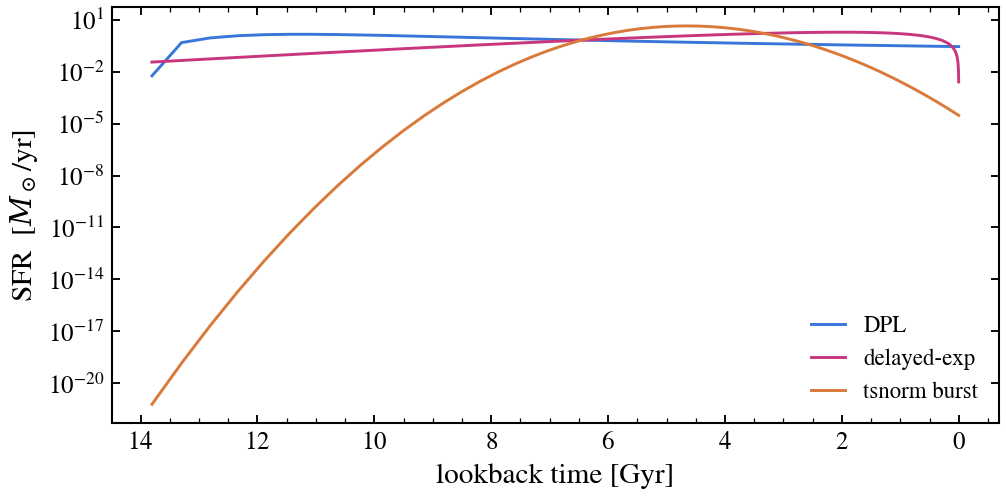

In [7]:
obs = Observation(
    photometry=Photometry.from_names(["sdss_u", "sdss_g", "sdss_r", "sdss_i", "wise_w1"])
)


def _build_sfh(sfh_factory):
    return SEDModel.build(
        ssp_data=ssp,
        observation=obs,
        sfh=sfh_factory(defaults=FIXED),
        dust={"type": "two_component", "law_bc": "calzetti", "all_params": FIXED},
        neb={"type": "none"},
        redshift=0.05,
    )


fig, ax = plt.subplots(figsize=(7, 3.6))
for name, factory, color in [
    ("DPL", builders.sfh.dpl, "#3a76d9"),
    ("delayed-exp", builders.sfh.dexp, "#c8377d"),
    ("tsnorm burst", builders.sfh.tsnorm, "#d97a3a"),
]:
    m = _build_sfh(factory)
    p = m.spec.sample(jax.random.PRNGKey(0))
    p = {**m.spec.get_fixed_values(), **p}
    s = m.predict_state(p)
    lbt_gyr = np.asarray(s.derived["sfh_grid_lbt_yr"]) / 1e9
    sfr = np.asarray(s.derived["sfr_history"])
    ax.plot(lbt_gyr, sfr, color=color, lw=1.4, label=name)
ax.invert_xaxis()
ax.set_xlabel("lookback time [Gyr]")
ax.set_ylabel(r"SFR  [$M_\odot$/yr]")
ax.set_yscale("log")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(FIG_DIR / "03_sfh_variants.png", dpi=300, bbox_inches="tight")

## Dust laws and IR templates

Attenuation laws — Calzetti, Cardelli (MW/LMC/SMC), Prevot SMC, Li 2008,
Witt & Gordon 2000, Conroy/Charlot–Fall variants — and IR re-emission
templates (Dale 2014, Draine–Li, THEMIS, Astrodust, BOSA, Casey 2012,
modified blackbody) all live under `tengri.components.dust`.

In [8]:
tengri.list_dust_laws()

name,status,citation,short_doc
calzetti,production,"Calzetti et al. 2000 (ApJ 533, 682)",Calzetti et al. starburst attenuation (R_V=4.05)
cardelli,production,"Cardelli et al. 1989 (ApJ 345, 245) MW extinction",Cardelli et al. MW extinction (parameterized R_V)
conroy2010,production,"Conroy et al. 2010 (ApJ 708, 58)",Conroy+10 mixed MW + power-law (FSPS default)
d03_mwrv31,production,"Draine 2003 (ARA&A 41, 241)",Draine 2003 MW R_V=3.1 grain model attenuation
hd23_mwrv31,production,"Hensley & Draine 2023 (ApJ 948, 55)",Hensley & Draine 2023 astrodust+PAH grain model
kriek_conroy,production,"Kriek & Conroy 2013 (ApJL 775, L16)",Kriek & Conroy modified Calzetti + bump + slope
leitherer02,production,"Leitherer et al. 2002 (ApJS 140, 303)",Leitherer et al. UV starburst attenuation
li08,production,"Li et al. 2008 (ApJ 685, 1046)",Li et al. analytical flexible attenuation curve
lmc,production,"Pei 1992 (ApJ 395, 130) LMC","LMC extinction (Pei 1992, weak bump)"
narayanan_z,production,"Narayanan et al. 2018 (ApJ 869, 70)",Narayanan et al. z-dependent attenuation (SIMBA)


In [9]:
tengri.list_dust_emission_models()

name,status,citation,short_doc
astrodust,experimental,"Hensley & Draine 2023 (ApJ 948, 55)",Astrodust + PAH unified grain model
bosa,experimental,Boquien et al. 2019 (CIGALE BOSA grids),BOSA dust SED templates
casey2012,production,"Casey 2012 (MNRAS 425, 3094)",Modified blackbody + mid-IR power law (analytic)
dale2014,production,"Dale et al. 2014 (ApJ 784, 83)",SFR-driven empirical IR template family (alpha_sf)
dale2014_cigale,production,"Dale et al. 2014 (ApJ 784, 83)","Dale+2014 IR templates, CIGALE alpha_sf + fracAGN parameterization"
dh02_ce01,production,,
dl07,production,"Draine & Li 2007 (ApJ 657, 810)","Diffuse + PAH grain mixture, Umin/Umax/qpah (alias of draine_li2007)"
dl07_tabulated,production,,
dl14,production,"Draine et al. 2014 (ApJ 780, 172)",Updated DL with extended PAH/silicate features (alias of draine_li2014)
draine2021_pah,production,,


## Nebular backends

- **`cue`** — neural emulator on Cloudy 17.03 (Li+2024). Fast, smooth,
  requires bare-stellar SSP.
- **`ssp`** — baked-in nebular contribution from a wNE SSP grid.
  Cheapest, locked to grid choices.
- **`cloudy`** — direct Cloudy evaluation. Accurate, slow.
- **`none`** — disable.

In [10]:
tengri.list_nebular_backends()

name,status,citation,short_doc
cb19,production,Charlot & Bruzual 2019 / Martinez-Paredes+2023 (3MdB_17),6D CB19 lines-only nebular grid (CB19Backend)
cloudy,production,Byler+2017 / Cloudy grids,Trilinear interp on Cloudy photoionization grid (CloudyGridBackend)
cue,production,Li et al. 2025 (CUE neural emulator),Neural-network Cloudy emulator with 12 free params (CueBackend)
none,production,,Disable nebular emission (continuum + lines)
ssp,production,DSPS / FSPS SSP-internal,Emission baked into SSP grid; zero free params (BakedInBackend)


## AGN composables

AGN is built from six orthogonal stages — disc, nlr, blr, feii, torus,
attenuation — each with its own registry of swappable blocks. The
composable blocks are the recommended surface for mixing and matching AGN
components. `recipes.agn_panchromatic()` is one stable composition.

In [11]:
tengri.list_agn_models()

name,status,citation,short_doc,param_details
composable,production,(no single paper — block recipe of registered tengri AGN blocks),Composable AGN: pick one block per stage (disc/nlr/blr/feii/torus/atten),"[{'name': 'agn_log_lbol', 'default': 'Uniform(8.0, 14.0)', 'description': 'AGN bolometric luminosity log10(L_bol / Lsun) — direct parametric mode'}, {'name': 'agn_lum_ratio', 'default': 'Uniform(0.0, 5.0)', 'description': ""AGN-to-stellar luminosity ratio (L_AGN / L_stellar_bol). Ranges to 5.0, so it is a ratio and not a fraction — which is why it is no longer called ``agn_frac`` (#1296). Used as a scalar multiplier on the composable runner output and as the AGN-to-stellar ratio in the non-parametric AGN path. Default 1.0 means 'use the configured AGN at full strength'; a wildcard ``'all_params': FIXED`` on an AGN-configured group therefore yields a working AGN (closes #417). Set explicitly to 0.0 to disable the AGN while keeping the rest of the agn config in place.""}]"


### Composable AGN blocks — discovery and mixing

The composable grammar groups blocks by pipeline stage. Use
`list_agn_blocks()` to see all available options, grouped by category.
Each block has a citation, status, and description accessible via
`describe_agn_block()`.

In [12]:
tengri.list_agn_blocks()

name,status,citation,short_doc,category
grahsp_biatten,production,"Buchner et al. 2024, arXiv:2405.19297",GRAHSP SMC-like broken power-law bi-attenuation,attenuation
none,production,,,attenuation
polar_dust,production,"Pei 1992, ApJ, 395, 130",Polar-dust extinction with Type-1-only screen,attenuation
qsogen,production,"Temple, Hewett & Banerji 2021, MNRAS, 508, 737",Temple+2021 empirical quasar extinction curve,attenuation
qsogen_smc,production,"Temple et al. 2021, MNRAS, 508, 737",Temple et al. 2021 QSOgen SMC reddening factor,attenuation
smc_prevot,production,"Prevot et al. 1984, A&A, 132, 389",Prevot et al. 1984 SMC extinction curve,attenuation
analytic,production,"Krawczyk et al. 2013, ApJS, 206, 4",Analytic broad-line region with Gaussian broadening,blr
grahsp,production,"Buchner et al. 2024, arXiv:2405.19297",GRAHSP Netzer 1990 broad-line Gaussians,blr
none,production,,,blr
qsogen,production,"Temple et al. 2021, MNRAS, 508, 737",Temple et al. 2021 QSOgen empirical broad-line region,blr


In [13]:
# Inspect a specific block
tengri.describe_agn_block("skirtor", category="torus")

name,skirtor
category,torus
kind,agn_block
status,production
citation,"Stalevski et al. 2016, MNRAS, 458, 2288"
short_doc,Stalevski et al. 2016 SKIRTOR torus with polar dust
use,"SEDModel.build(..., agn={'torus': {'type': 'skirtor'}})"


## Recipes — five curated starting points

In [14]:
print(list(recipes.__all__))

['agn_panchromatic', 'composable_agn', 'dust_demo', 'high_z', 'mock_recovery_minimal', 'photoz', 'quiescent_z0', 'star_forming_photometry', 'stochastic_sfh_jwst', 'unified_agn']


In [15]:
recipes.star_forming_photometry()

{'sfh': {'type': 'dpl', 'all_params': FREE},
 'dust': {'type': 'two_component',
  'all_params': FREE,
  'law_bc': 'calzetti',
  'law_diff': 'calzetti',
  'emission': {'type': 'dale2014', 'all_params': FIXED}},
 'neb': {'type': 'cue', 'all_params': FIXED},
 'redshift': Uniform(0.01, 6.0),
 'apply_igm': True,
 'approx': WavePrecomp(n_z=250, z_min=None, z_max=None, catalog_z_range=None, band_integration='quadrature', n_subbands=5, taylor_correction=False, fast_dust_emission=False)}

## Inference backends

The `status` column reports whether each backend's dependencies are
importable. Compatibility against a specific model is rechecked at
`Fitter.run` time.

In [16]:
tengri.list_inference_methods()

name,tier,status,short_doc
laplace,primary,ok,"Laplace approximation around the MAP (cold ~5-9s, warm ~1-2s, ~3 GB)"
map,primary,ok,Adam MAP optimization
mcmc,primary,ok,"Auto MCMC: NUTS for low-D, raytrace for high-D"
mcmc_hmc,primary,ok,"Hamiltonian Monte Carlo (cold ~21s, ~5 GB on D=6-7). Convergence-validated only with dense_mass_matrix=True, n_warmup≥1000, n_leapfrog_steps≥20 on D=6 DPL (R-hat 1.008, ESS 411). Default n_warmup=300 / dense=True gives R-hat ≫ 1 — do not lower the warmup for science."
mcmc_nuts,primary,ok,No-U-Turn Sampler (cold ~90s at D=6 DPL; warmup blows past 5 min on dense_basis D=7 — prefer mcmc_hmc or mcmc_ghmc for dense_basis SFH)
mcmc_raytrace,primary,ok,Ray-tracing ensemble sampler (high-D)
vi,primary,ok,"NIFTy geoVI variational inference (cold ~100s, ~20 GB RSS at D=6-7 — memory-heavy; consider mcmc_hmc for faster turnaround on D<10)"
vi_nonlinear_fast,primary,ok,NIFTy geoVI without Python logging
mcmc_adjusted_mclmc,experimental,ok,"Adjusted microcanonical Langevin (cold ~60s, ~3x compile premium over mclmc). Requires blackjax >= 1.6."
mcmc_dynamic_hmc,experimental,ok,"Dynamic HMC — fast (cold ~19s) but chains under-mix at default settings (R-hat ≈ 1.11-1.25, ESS ≈ 1-30 on D=6-7 mocks, 1000 warmup + 2000 samples). Needs tuning before science use."


## Parameter and physics provenance

Two introspection surfaces close the loop:
`model.spec.summary()` tags every parameter with where its value came
from (`[user]` / `[all_params FREE]` / `[all_params FIXED]` / `[default]`).
`citations.collect_citations(model)` returns the bibliography of every
physics ingredient.

In [17]:
example = SEDModel.build(ssp_data=ssp, observation=obs, **recipes.star_forming_photometry())
example.spec.summary()

/Users/suchethacooray/Projects/tengri/src/tengri/forward/sed_model.py:7796: WildcardPartialFreeWarning: 'all_params: FREE' freed 2 of 3 parameters in group 'dust'. These have no declared prior, only Fixed defaults, so they stay pinned:
  dust_f_obscuration
The fit will run with that physics held constant. Pass explicit priors for the ones you meant to vary, e.g. dust={'f_obscuration': Uniform(lo, hi)}, or filter WildcardPartialFreeWarning if this is deliberate.
  spec = parse_groups(**groups)
/Users/suchethacooray/Projects/tengri/src/tengri/forward/sed_model.py:7796: WildcardPartialFreeWarning: 'all_params: FREE' freed 6 of 8 parameters in group 'sfh'. These have no declared prior, only Fixed defaults, so they stay pinned:
  met_alpha_fe, met_logzsol_scatter
The fit will run with that physics held constant. Pass explicit priors for the ones you meant to vary, e.g. sfh={'met_alpha_fe': Uniform(lo, hi)}, or filter WildcardPartialFreeWarning if this is deliberate.
  spec = parse_groups(**

Parameters  SFH: dpl
──────────────────────────────────────────────────────────────────
  Dimensions:  9 free, + 40 fixed
  Modules:     nebular=cue, dust_emission=dale2014, igm, dust_law=calzetti/calzetti

  Parameter                        Prior                      Bounds                 Source
  ──────────────────────────────────────────────────────────────────────────────────────────
  dust_tau_bc                      Uniform(0.0, 4.0)          [0, 4]                 [all_params FREE]
  dust_tau_diff                    Uniform(0.0, 3.0)          [0, 3]                 [all_params FREE]
  met_logzsol                      Uniform(-2.0, 0.2)         [-2, 0.2]              [all_params FREE]
  redshift                         Uniform(0.01, 6.0)         [0.01, 6]              [user]
  sfh_dpl_age_gyr                  Uniform(0.5, 13.81)        [0.5, 13.81]           [all_params FREE]
  sfh_dpl_alpha                    Uniform(0.1, 5.0)          [0.1, 5]               [all_params FREE]
 

In [18]:
bib = citations.collect_citations(example)
citations.print_citations(example)

Please cite the following when publishing results that use tengri:

  [1] Cooray et al. (2026, Paper I)  —  SED fitting framework — methods paper (this package)
       {tengri: Differentiable SED fitting with Information-Field-Theory star formation history priors. I. Framework and mock recovery}

  [2] Bradbury et al. (2018)  —  Autodiff framework and XLA compiler integration
       {JAX}: composable transformations of {P}ython+{N}um{P}y programs
       code: jax-ml/jax

  [3] Hearin et al. (2023)  —  Differentiable stellar population synthesis engine
       {DSPS: Differentiable stellar population synthesis}
       DOI: 10.1093/mnras/stad456   arXiv: 2112.06830   code: ArgonneCPAC/dsps

  [4] Oke \& Gunn (1983)  —  AB magnitude system / absolute spectrophotometric zero point
       {Secondary standard stars for absolute spectrophotometry.}
       DOI: 10.1086/160817

  [5] Hogg et al. (2002)  —  Photon-counting bandpass AB flux (Eq.~5); K-correction formalism
       {The K correction}

Export to BibTeX in one call:

In [19]:
bibtex = citations.citations_bibtex(example)
print(bibtex[:600], "…")

@article{Cooray_2026,
  author = {{Cooray}, Suchetha},
  title = {{tengri: Differentiable SED fitting with Information-Field-Theory star formation history priors. I. Framework and mock recovery}},
  year = {2026},
  journal = {in preparation},
}

@article{Jamesbradbury_2018,
  author = {James Bradbury and Roy Frostig and Peter Hawkins and Matthew James Johnson and Chris Leary and Dougal Maclaurin and George Necula and Adam Paszke and Jake Vander{P}las and Skye Wanderman-{M}ilne and Qiao Zhang},
  title = {{JAX}: composable transformations of {P}ython+{N}um{P}y programs},
  year = {2018},
}

@a …


## Cache and memory

- **`tengri.lean`** — context manager / default mode. Drops the
  per-Fitter JIT engine after each `run` to release graph memory.
- **`tengri.persistent`** — opposite mode. Keep the engine for
  repeated same-shape fits (population sweep, MCMC restart).
- **`tengri.gc`** — one-shot collect: clears shared caches and asks
  XLA to release the device.
- **`tengri.clear_shared_caches()`** — full reset for clean
  benchmarking.

The persistent JAX compile cache (`~/.cache/tengri_jax_cache`,
auto-enabled by `import tengri`) is independent of these — it survives
process restarts.

## Cross-namespace search

`tengri.search("term")` queries every registry at once.

In [20]:
tengri.search("Calzetti")

name,kind,status,citation,short_doc,use
single_component,dust_model,production,"Calzetti et al. 2000 (ApJ 533, 682)",One screen over all stars; `law_bc` sets the curve,"SEDModel.build(..., dust={'type': 'single_component'})"
calzetti,dust_attenuation,production,"Calzetti et al. 2000 (ApJ 533, 682)",Calzetti et al. starburst attenuation (R_V=4.05),"SEDModel.build(..., dust={'type': 'single_component', 'law_bc': 'calzetti'})"
kriek_conroy,dust_attenuation,production,"Kriek & Conroy 2013 (ApJL 775, L16)",Kriek & Conroy modified Calzetti + bump + slope,"SEDModel.build(..., dust={'type': 'single_component', 'law_bc': 'kriek_conroy'})"
noll09,dust_attenuation,production,"Noll et al. 2009 (A&A 507, 1793)",Noll et al. modified Calzetti + L02 + bump + slope,"SEDModel.build(..., dust={'type': 'single_component', 'law_bc': 'noll09'})"
salim,dust_attenuation,production,"Salim et al. 2018 (ApJ 859, 11)",Salim et al. modified Calzetti (DSPS default),"SEDModel.build(..., dust={'type': 'single_component', 'law_bc': 'salim'})"
salim_sbl18,dust_attenuation,production,"Salim et al. 2018 (ApJ 859, 11)","Salim, Boquien & Lee modified Calzetti + L02","SEDModel.build(..., dust={'type': 'single_component', 'law_bc': 'salim_sbl18'})"


## Sub-namespaces — where to look for what

- **`tengri.cosmology`** — Planck 2018 distance and time integrals
  (`luminosity_distance_mpc`, `age_at_z`, …).
- **`tengri.units`** — F_ν ↔ L_ν ↔ AB-mag conversions, vacuum-air, Jy.
- **`tengri.plot`** — `plot_sed_fit`, `plot_sfh`, `plot_corner_comparison`,
  `setup_style`, `diagnostics_table`. Re-exports of
  `tengri.analysis.plotting`.
- **`tengri.observation`** — `Photometry`, `Spectroscopy`, `Observation`,
  `NoiseModel`, `LineList`, filter loaders.
- **`tengri.inference`** — `Catalog` (many galaxies, one call),
  `VIConfig`, `InferenceContext`. Single-galaxy fits go through
  `ForwardModel.fit`; `Fitter` is an internal engine, not a surface to
  call directly.
- **`tengri.results`** — `Posterior`, `CatalogPosterior`,
  `PopulationPosterior`, `FitResult`, `MockData`, `Provenance`,
  `generate_mock`.
- **`tengri.config`** — `SEDModelConfig`, `SFHConfig`, `DustConfig`,
  `NebularConfig`, `AGNConfig`.
- **`tengri.protocols`** — Protocol shapes (`SEDComponent`, `Likelihood`,
  `ObservationModel`, `DerivedKey`, `ForwardState`).
- **`tengri.builders`** — config-dict factories with introspectable
  signatures (`builders.sfh.*`, `builders.dust.*`, `builders.neb.*`,
  `builders.agn.*`, `builders.igm.*`).
- **`tengri.citations`** — `Bibliography`, `Citation`,
  `collect_citations`, `citations_report`, `citations_bibtex`,
  `print_citations`, `print_bibtex`, `paper_citation`.

From here: try `tengri.help()` for topic-indexed pointers, or
`dir(tengri.components.<area>)` for any physics sub-namespace.